### Verification and Training Errors



In [2]:
reg = '250_350r'
save_loc = 'first'

network_inf = f'nets/consis/{reg}/{save_loc}.pt'
save = f'figures/consis/{reg}/{save_loc}.png'

In [3]:
'load the net set up for eval'
import torch
from Modules.Neural_Net import Net
model = torch.load(network_inf, weights_only=False)
scaler_in, scaler_out = model['scalers']

net = Net(torch.sin, *model['model config'])
net.load_state_dict(model['model_state_dict'])

net.to('cuda')
net.eval()


'done'

'done'

In [4]:
import torch
import Modules.preprocess as pp
import numpy as np 
import re

step = 2

data  = torch.load('../../data/data.pt', weights_only=True)

nums = re.findall(r'\d+', network_inf)  
first, second = map(int, nums[:2]) 
frames = np.arange(first, second, step=step)

train_beams = range(0,32)

model = torch.load(network_inf, weights_only=False)

scaler_in, scaler_out = model['scalers']
masker = model['masker']

datasets = pp.data_gen(data, beams = train_beams, frames=frames, normalize=model['scalers'], masker = masker)
train_dataloader, ver_dataloader  = datasets.get_dataloaders(batch_size=1, num_workers=4)
 

we are in the siren section


In [5]:
import numpy as np
import torch
from Modules.evaluate import Evaluator
import matplotlib.pyplot as plt

'Store frame error in list'
all_diff = []

net.to('cpu')
with torch.no_grad():
    for inputs, d in train_dataloader:

        eval = Evaluator(net, scalers = model['scalers'], inputs = inputs)
        pred, unscaled_inputs, targets = eval.net_eval_scaled(d)


        diff = pred - targets
        diff = diff.reshape(-1, 1)
        all_diff.append(diff)

# get all points together
error = torch.concatenate(all_diff)
error = error.cpu().numpy()

ver_all_diff = []

with torch.no_grad():
    for inputs, vd in ver_dataloader:
        eval = Evaluator(net, scalers = model['scalers'], inputs = inputs)
        preds_np, unscaled_inputs, targets = eval.net_eval_scaled(vd)
        err = (preds_np - targets) #signed distance between points
        ver_all_diff.append(err.ravel())

ver_error =  np.concatenate(ver_all_diff)



<>:55: SyntaxWarning: invalid escape sequence '\s'
<>:55: SyntaxWarning: invalid escape sequence '\s'
C:\Users\dculv\AppData\Local\Temp\ipykernel_18028\2673148404.py:55: SyntaxWarning: invalid escape sequence '\s'
  color = "#4b8692ff", label = f"mean = {ver_mean:.2f} m , $\sigma$ = {vrms:.2f} m", density = True )  # count on log scale


0.1380238
0.138


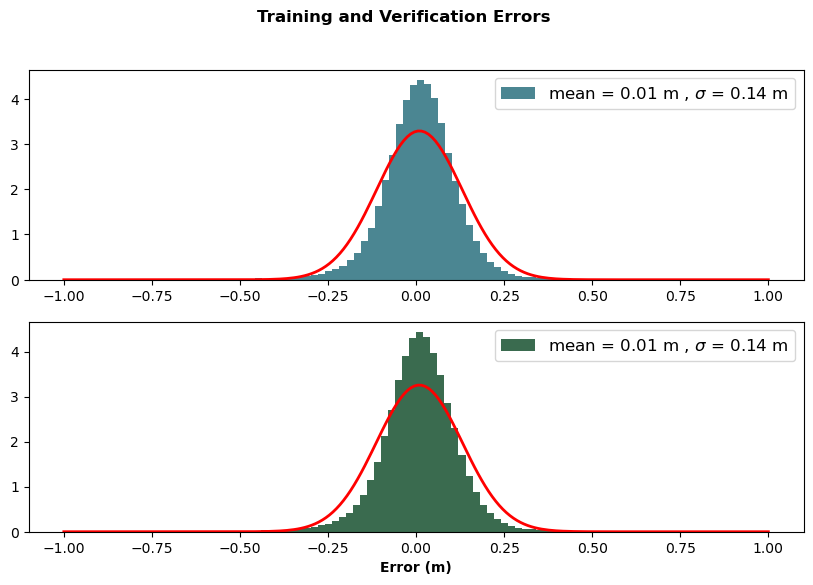

In [6]:
import matplotlib.pyplot as plt
import numpy as np
print((error).std())

rms = round(np.sqrt(((error)**2).mean()),3)

vrms = round(np.sqrt(((ver_error)**2).mean()), 3)

print(rms)
r = 1

mask = (error <r) & (error> -r) 
vmask = (ver_error <r) & (ver_error> -r) 

r_e = error[mask]
r_ve = ver_error[vmask]

from scipy.stats import norm

mean = r_e.mean()
ver_mean = r_ve.mean()
std = r_e.std()
ver_std = r_ve.std()
xmin, xmax = [-r,r]
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, loc = mean, scale = std)
ver_p = norm.pdf(x,  loc = ver_mean, scale = ver_std)
log = True
# fig, (ax1, ax2) = plt.subplots(2, figsize = (10,6))

# ax1.hist(r_ve, bins=100, log=log,
# color = "#4b8692ff", label = f"Verification Error: {vrms:.2f}", density = True )  # count on log scale
# ax2.hist(r_e, bins = 100, log = log,
# color = "#3a6b4fff", label = f"Training Error: {rms:.2f}", density = True)

# ax1.plot(x, ver_p, color= 'red', linewidth =2)
# ax2.plot(x,p, color = 'red', linewidth =2)

# # ax1.set_yscale('log')
# # ax2.set_yscale('log')



# ax1.legend(fontsize = 'large', loc = 'upper right')
# ax2.legend(fontsize = 'large', loc = 'upper right')
# ax2.set_xlabel("Error (m)", fontweight = 'bold')


# plt.suptitle('Training and Verification Errors', fontweight = 'bold')
# plt.show()

fig, (ax1, ax2) = plt.subplots(2, figsize = (10,6))

ax1.hist(r_ve, bins=100, log=not(log),
color = "#4b8692ff", label = f"mean = {ver_mean:.2f} m , $\sigma$ = {vrms:.2f} m", density = True )  # count on log scale
ax2.hist(r_e, bins = 100, log = not(log),
color = "#3a6b4fff", label = rf"mean = {mean:.2f} m , $\sigma$ = {rms:.2f} m", density = True)

ax1.plot(x, ver_p, color= 'red', linewidth =2)
ax2.plot(x,p, color = 'red', linewidth =2)

# ax1.set_yscale('log')
# ax2.set_yscale('log')



ax1.legend(fontsize = 'large', loc = 'upper right')
ax2.legend(fontsize = 'large', loc = 'upper right')
ax2.set_xlabel("Error (m)", fontweight = 'bold')


plt.suptitle('Training and Verification Errors', fontweight = 'bold')
plt.savefig(save , dpi = 300)
plt.show()

In [8]:
list = [r_ve, r_e, ver_mean, mean, vrms, rms, x, p, ver_p]
import pickle
pickle.dump(list, open(f'C:\\Users\\dculv\\OneDrive\\Documents\\Scripps_Research\\NN_and_Waves\\paper\\latex\\scripts\\fig2_3plots\\hist.pkl', 'wb'))

In [61]:
print(model['model config'])

(3, 280, 550, 550, 280, 100, 100)


In [ ]:
from Modules.evaluate import Evaluator


net.to('cpu')
all_diff = []
for inputs, targets in train_dataloader:
    eval = Evaluator(net = net, inputs = inputs, scalers = model['scalers'])

    pred, unscaled_inputs, targets = eval.net_eval_scaled(targets)

    diff = pred - targets
    diff = diff.reshape(-1, 1)
    all_diff.append(diff)
z = torch.concatenate(all_diff)

In [ ]:
from Modules.evaluate import Evaluator


net.to('cpu')
all_diff = []
for inputs, targets in train_dataloader:
    eval = Evaluator(net = net, inputs = inputs, scalers = model['scalers'])

    pred, unscaled_inputs, targets = eval.net_eval_scaled(targets)

    diff = pred - targets
    diff = diff.reshape(-1, 1)
    all_diff.append(diff)
z = torch.concatenate(all_diff)

## Surface Discrepancy Plots

In [2]:
import torch

reg = '250_350r'

network1 = f'nets/consis/{reg}/first.pt'
network2 = f'nets/consis/{reg}/second.pt'
save = f'figures/consis/{reg}/disc/'
t = torch.linspace(25, 35, 100)


In [3]:
def add_t(tensor, time):
    return torch.cat([tensor, torch.ones_like(tensor[:, 0]).unsqueeze(1)*time], dim=1).to(dtype=torch.float32)

In [4]:
from Modules.Neural_Net import Net
from Modules.evaluate import Evaluator
import torch


model1 = torch.load(network1, weights_only=False)
model2 = torch.load(network2, weights_only=False)

net1 = Net(torch.sin, *model1['model config'])
net2 = Net(torch.sin, *model2['model config'])

net1.load_state_dict(model1['model_state_dict'])
net2.load_state_dict(model2['model_state_dict'])

inputs = torch.load('Modules/plotting_region.pt', weights_only= True)

x = inputs[:, 0:1].cpu().detach().numpy()
y = inputs[:, 1:2].cpu().detach().numpy()

scaler1 = model1['scalers']
scaler2 = model2['scalers']


In [5]:
def get_diff(time):
    xyt = add_t(inputs, time)

    eval1 = Evaluator(net = net1, scalers = scaler1, inputs = xyt)
    eval2 = Evaluator(net = net2, scalers = scaler2, inputs = xyt)

    pred1= eval1.net_eval()
    pred2= eval2.net_eval()

    diff = pred2 - pred1

    z = diff.cpu().detach().numpy()

    ad = round(z.mean(), 3)
    std = round(z.std(), 3)

    # plt.scatter(xyt[:,0], xyt[:,1], c = pred2, cmap = cmc.davos, vmin = 0, vmax = 6)
    # plt.show()
    return z, ad, std


In [6]:
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import os

def plot(x,y, z, ad,std, i, save_path):
    fig, ax = plt.subplots(figsize = (9,4))
    sc = ax.scatter(x,y,c =z, cmap = cmc.vik, vmin = -.5, vmax =.5, label = rf'Average Difference: {ad:.3f} (m), $\sigma$: {std:.3f} (m)')
    cbar = fig.colorbar(sc, ax=ax, label = "meters")
    ax.legend()

    ax.set_xlim(-255, -133)
    ax.set_ylim(-180, -145)

    ax.set_xlabel('Cross Shore', fontweight = 'bold')
    ax.set_ylabel('Along Shore', fontweight = 'bold')
    ax.set_title(r'Difference of $\eta_1$ and $\eta_2$', fontsize = 12, fontweight = 'bold')
    
    save = os.path.join(save_path,f"{i:04d}.png")

    plt.savefig(save, dpi =300)
    plt.close()

In [ ]:
import pickle

time = 30
z,ad,std = get_diff(time)
plot(x,y,z,ad, std, 0, '')

list = [x,y,z, ad, std, time]
pickle.dump(list, open(f'info.pkl', 'wb'))

In [10]:
for i, time in enumerate(t):
    z,ad,std = get_diff(time)
    plot(x,y,z,ad, std, i, save)

### Here we make plots of the training data vs validation data vs testing data

In [1]:
import torch
from Modules import pre_pro
from Modules.Neural_Net import Net
from Modules.Neural_Net import NetWrapper
from tqdm import tqdm
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import numpy as np
from torch.utils.data import DataLoader
import seaborn




### Training Data

In [2]:
'Iterate through dataloader taking rms errors.'


data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(250,350, 1)
device = 'cuda'

beams = list(range(6, 20))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)

dataset = pre_pro.FrameDataset(input, output)
spt_dataloader = DataLoader(dataset, shuffle=True, batch_size=1)


In [3]:
network_info = torch.load('nets/SPT/spt_e_10000_a_5.pt', weights_only=True)
net = Net(torch.cos, *network_info['model config'])
net.load_state_dict(network_info['model_state_dict'])
net.to('cuda')

'hi'

'hi'

In [4]:
network_info = torch.load('nets/MSE/MSE_250_350.pt', weights_only=True)
mse_net = Net(torch.cos, *network_info['model config'])
mse_net.load_state_dict(network_info['model_state_dict'])
mse_net.to('cuda')

'hi'

'hi'

In [9]:
'error at each point in space and time'
stats = []

with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = net(batch_x)
        nrms = torch.sqrt(((pred_y - batch_y)/.06)**2).reshape(-1).cpu().numpy()
        stats.append(nrms)


mse_stats = []

with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = mse_net(batch_x)
        nrms = torch.sqrt(((pred_y - batch_y)/.06)**2).reshape(-1).cpu().numpy()
        mse_stats.append(nrms)


 Regulrized NRMS: 1.378644347190857, MSE NRMS: 1.4603949785232544


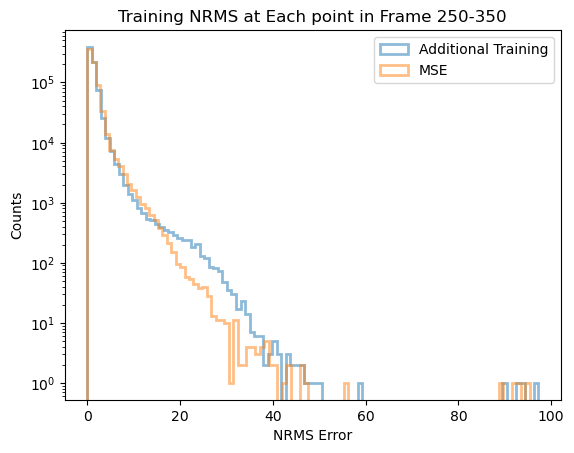

In [12]:
results = np.concatenate(stats)
mse_results = np.concatenate(mse_stats)

print(f' Regulrized NRMS: {results.mean()}, MSE NRMS: {mse_results.mean()}')

att = dict(histtype='step', linewidth = 2, alpha=0.5)
plt.hist(results, bins=100, **att, color='C0', label='Additional Training')
plt.hist(mse_results, bins=100, **att, color='C1', label='MSE')
plt.yscale('log')
plt.xlabel('NRMS Error')
plt.ylabel('Counts')
plt.title('Training NRMS at Each point in Frame 250-350')
plt.legend()
plt.show()

In [10]:
stats = []
k=0
with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = net(batch_x)
        nrms = torch.sqrt(torch.mean((pred_y - batch_y)**2)).item()*100
        stats.append(nrms)



In [5]:
avg_error = sum(stats)/len(stats)
print(f'Average RMS Error: {avg_error} cm')

Average RMS Error: 32.32579617202282 cm


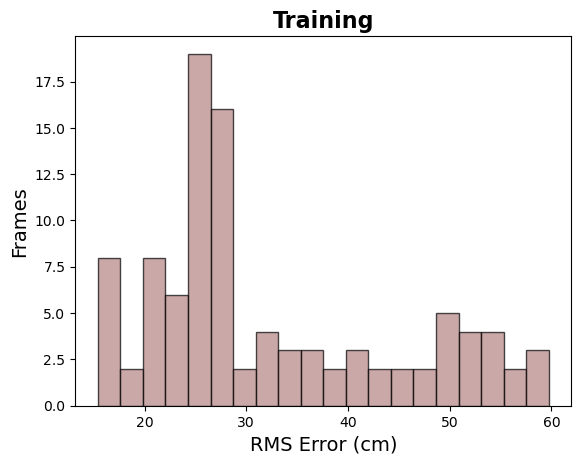

In [6]:
plt.hist(stats, bins=20, density=False, alpha=0.7, color="#B48383", edgecolor='black')
plt.xlabel('RMS Error (cm)', fontsize = 14)
plt.ylabel('Frames', fontsize = 14)
plt.title('Training', fontweight = 'bold', fontsize = 16)
plt.show()


## Testing

In [13]:
'Iterate through dataloader taking rms errors.'


data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(250,350, 1)
device = 'cuda'

beams =[4,30]
# indices_to_remove = [10, 11]
# beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)

dataset = pre_pro.FrameDataset(input, output)
spt_dataloader_test = DataLoader(dataset, shuffle=True, batch_size=1)


In [10]:
stats_test = []
k=0
with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader_test:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = net(batch_x)
        nrms = torch.sqrt(torch.mean((pred_y - batch_y)**2)).item()*100
        stats_test.append(nrms)


In [13]:
avg_error_test = sum(stats_test)/len(stats_test)
print(f'Average RMS Error (Test Beams): {avg_error_test} cm')

Average RMS Error (Test Beams): 31.46412968635559 cm


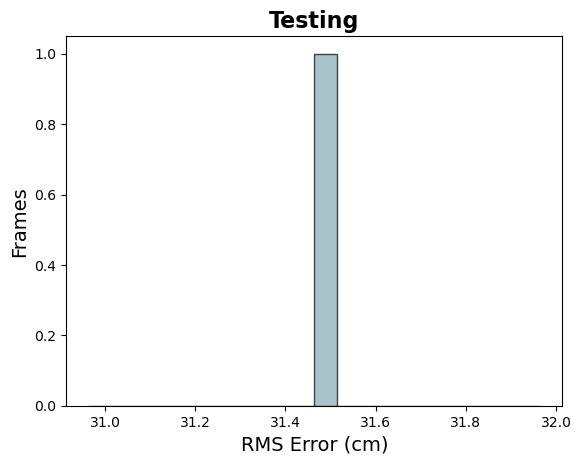

In [14]:
plt.hist(stats_test, bins=20, density=False, alpha=0.7, color="#83ACB4", edgecolor='black')
plt.xlabel('RMS Error (cm)', fontsize = 14)


plt.ylabel('Frames', fontsize = 14)

plt.title('Testing', fontweight = 'bold', fontsize = 16)
plt.show()

In [14]:
'one frame'


stats_test = []

with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader_test:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = net(batch_x)
        nrms = torch.sqrt(((pred_y - batch_y)/.06)**2).reshape(-1).cpu().numpy()
        stats_test.append(nrms)


mse_stats_test = []

with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader_test:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = mse_net(batch_x)
        nrms = torch.sqrt(((pred_y - batch_y)/.06)**2).reshape(-1).cpu().numpy()
        mse_stats_test.append(nrms)


Regulirezed NRMS: 3.3633065223693848, MSE NRMS: 1.8125994205474854


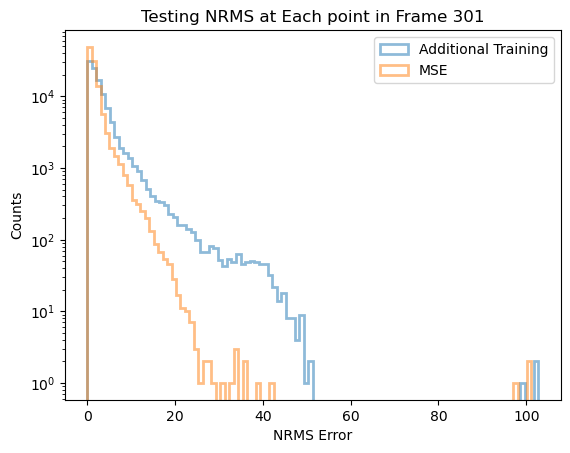

In [16]:
results = np.concatenate(stats_test)
mse_results = np.concatenate(mse_stats_test)

print(f'Regulirezed NRMS: {results.mean()}, MSE NRMS: {mse_results.mean()}')

att = dict(histtype='step', linewidth = 2, alpha=0.5)
plt.hist(results, bins=100, **att, color='C0', label='Additional Training')
plt.hist(mse_results, bins=100, **att, color='C1', label='MSE')
plt.yscale('log')
plt.xlabel('NRMS Error')
plt.ylabel('Counts')
plt.title('Testing NRMS at Each point in Frame 301')
plt.legend()
plt.show()

In [ ]:
from Modules.evaluate import Evaluator


net.to('cpu')
all_diff = []
for inputs, targets in train_dataloader:
    eval = Evaluator(net = net, inputs = inputs, scalers = model['scalers'])

    pred, unscaled_inputs, targets = eval.net_eval_scaled(targets)

    diff = pred - targets
    diff = diff.reshape(-1, 1)
    all_diff.append(diff)
z = torch.concatenate(all_diff)